# MLFlow for Kaggle II - Loan Approval Prediction

In this notebook we will use the Loan Approval dataset to demonstrate how to build a machine learning pipeline using the MLFlow library. We will use the following steps:

1. Data Collection
2. Data Exploration
3. EDA - Exploratory Data Analysis
4. Data Preprocessing
5. Model Selection
6. Model Training
7. Model Evaluation
8. Model Optimization
9. Model Tracking
10. Kaggle Submission


## 1. Data Collection

### Loan Approval Prediction

Go to the [Loan Approval Prediction Competition](https://www.kaggle.com/competitions/playground-series-s4e10/overview). **Join the competition** and accept the terms and conditions.

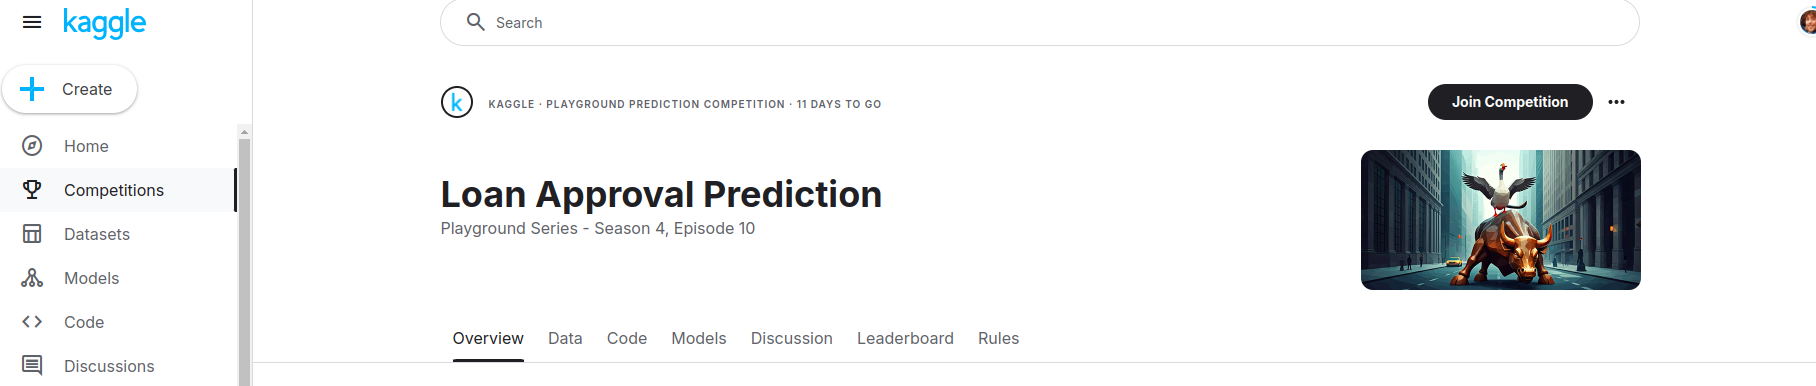

Now **download the data manually** by going to `Data` > `Download Data`

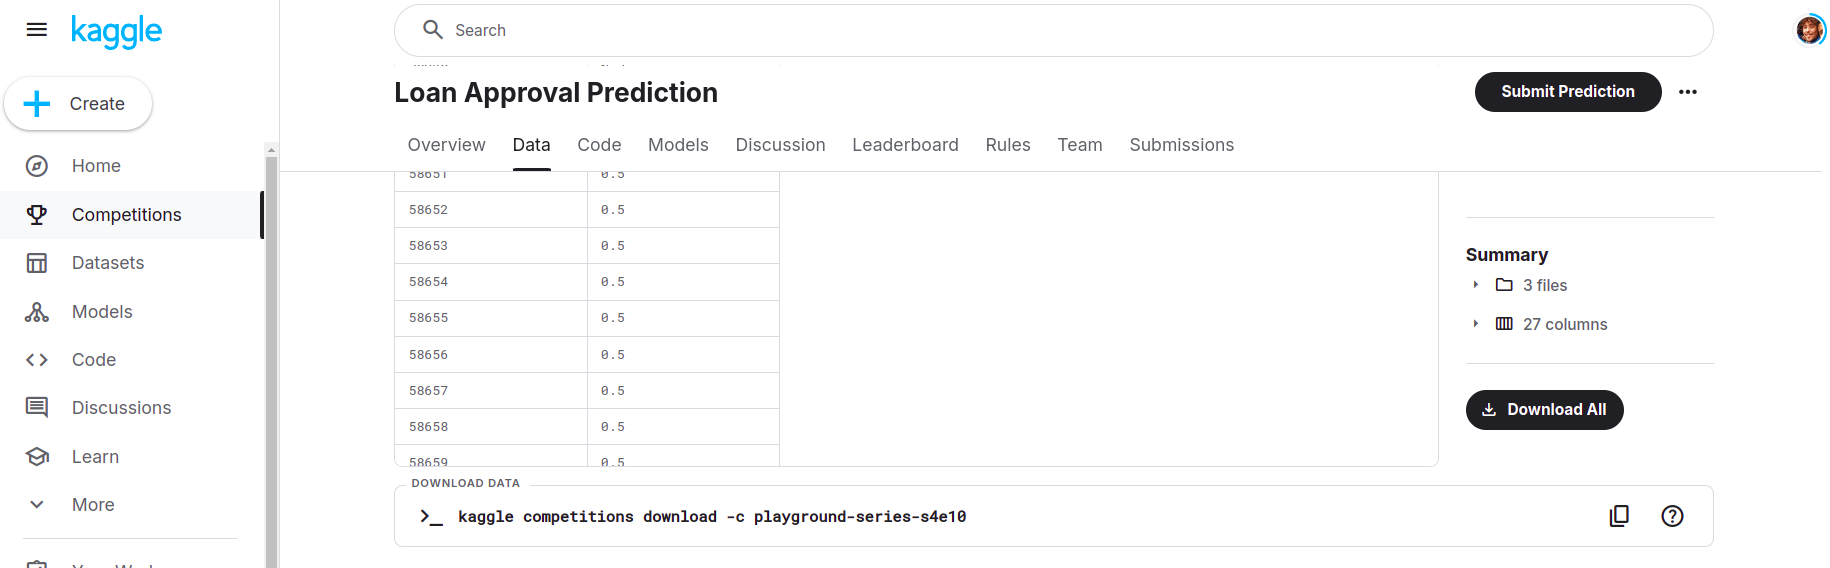

Once we've downloaded the data we are going to save it into `data/loan_prediciton`. We can see there are three files:

- `train.csv`: The training data
- `test.csv`: The test data
- `sample_submission.csv`: The sample submission file

ℹ️ Remember that `test.csv` does not have the target column, we will use it to evaluate our model against the kaggle platform.

## 2. Data Exploration

Let's load the data and take a look at the first few rows.

In [1]:
import pandas as pd


DATA_FOLDER = "../data/loan_prediction/"
TRAIN_CSV_PATH = DATA_FOLDER + "train.csv"
TEST_CSV_PATH = DATA_FOLDER + "test.csv"


train_df = pd.read_csv(TRAIN_CSV_PATH, index_col='id')
test_df = pd.read_csv(TEST_CSV_PATH, index_col='id')

train_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
id,,,,,,,,,,,,
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


**Feature Descriptions**

- person_age: Applicant’s age in years.
- person_income: Annual income of the applicant in USD.
- person_home_ownership: Status of homeownership (e.g., Rent, Own, Mortgage).
- person_emp_length: Length of employment in years.
- loan_intent: Purpose of the loan (e.g., Education, Medical, Personal).
- loan_grade: Risk grade assigned to the loan, assessing the applicant’s creditworthiness.
- loan_amnt: Total loan amount requested by the applicant.
- loan_int_rate: Interest rate associated with the loan.
- loan_percent_income: Percentage of the applicant’s income allocated towards loan repayment.
- cb_person_default_on_file: Indicates if the applicant has a history of default ('Y' for yes, 'N' for no).
- cb_person_cred_hist_length: Length of the applicant’s credit history in years.
- loan_status: The approval status of the loan (1 for rejected, 0 for approved).

In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  str    
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  str    
 5   loan_grade                  58645 non-null  str    
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  str    
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 6.4 MB


## 3. EDA - Exploratory Data Analysis

Let's dive into the data and understand it better. In order to do so we import the plotting libraries.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.





We will look at the following:

- Distribution of the loan amount


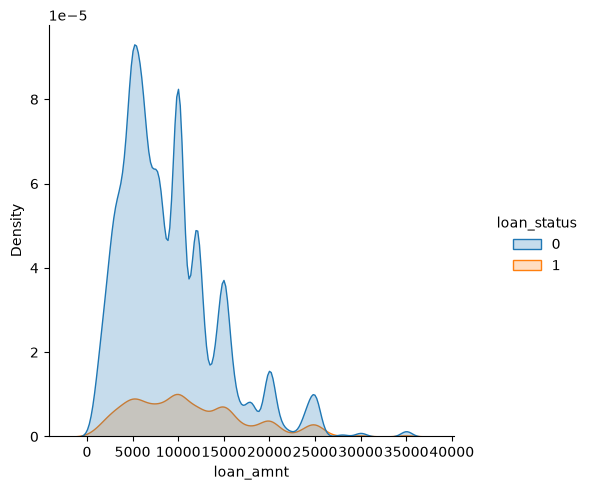

In [4]:
ax = sns.displot(train_df, x='loan_amnt', hue='loan_status', kind='kde', fill=True)

- Distribution of the applicant income

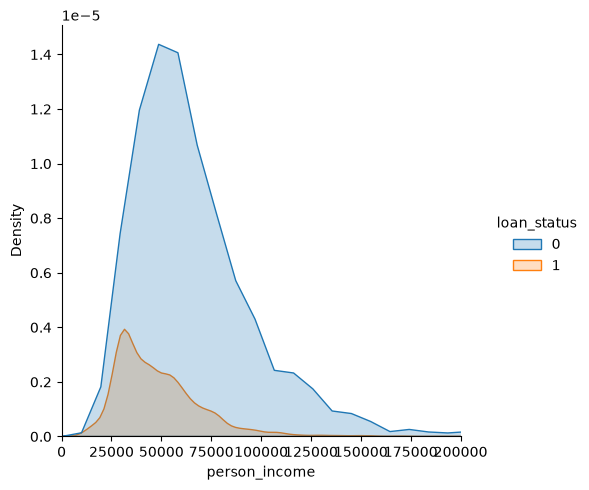

In [5]:
ax = sns.displot(train_df, x='person_income', hue='loan_status', kind='kde', fill=True)
ax.set(xlim=(0, 200000))

- person income vs loan amount

[(0.0, 200000.0)]

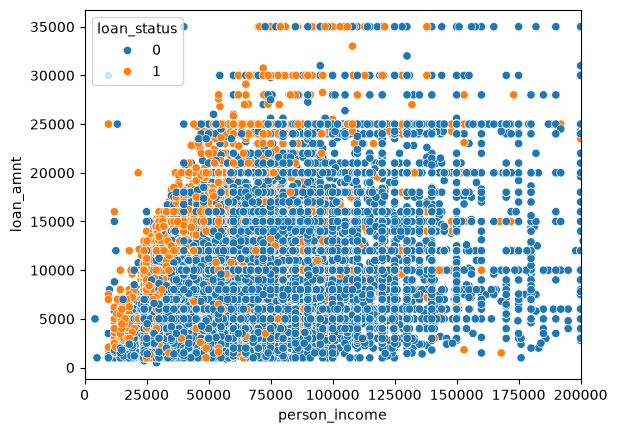

In [6]:
ax = sns.scatterplot(data=train_df, x='person_income', y='loan_amnt', hue='loan_status')
ax.set(xlim=(0, 200000))

- Loan Percent Income

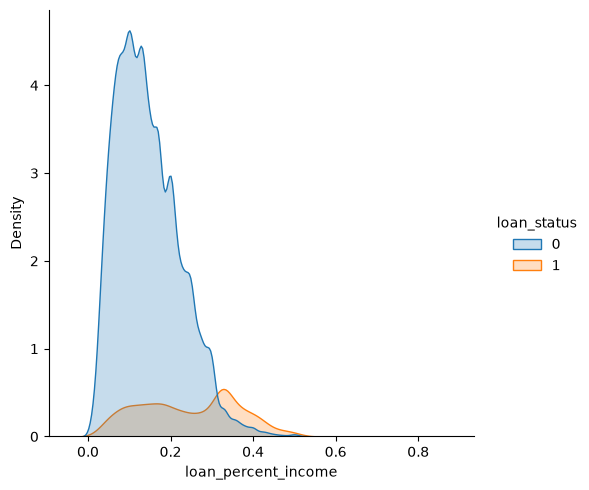

In [7]:
ax = sns.displot(train_df, x='loan_percent_income', hue='loan_status', kind='kde', fill=True)

## 4. Data Preprocessing

Remember that we need to preprocess the data before training the model. We will do the following steps:

- Encode the categorical columns
- Scale the numerical columns


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_features = [
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
]

cat_features = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file',
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(), cat_features),
    ]
)

## 5. Model Selection

We will use a Random Forest Classifier to predict the loan approval status.

In [9]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier


base_model = RandomForestClassifier(n_estimators=100, random_state=42)

We are going to create a **Pipeline**. This drastically simplifies the process of building a machine learning model because it bundles the preprocessing and the model into a single object.

In [10]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('base_model', base_model),
])

## 6. Model Training

Split the data into train and validation sets.

In [11]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

X = train_df.drop(columns=['loan_status'])
y = train_df['loan_status']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [12]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('base_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

## 7. Model Evaluation

We use the area under the ROC curve to evaluate the model.

In [13]:
from sklearn.metrics import roc_auc_score


y_pred = pipeline.predict(X_val)
auc_metric = roc_auc_score(y_val, y_pred)

print(f'AUC: {auc_metric:.4f}')

AUC: 0.8538


Display the ROC Curve

Text(0.5, 1.0, 'ROC Curve')

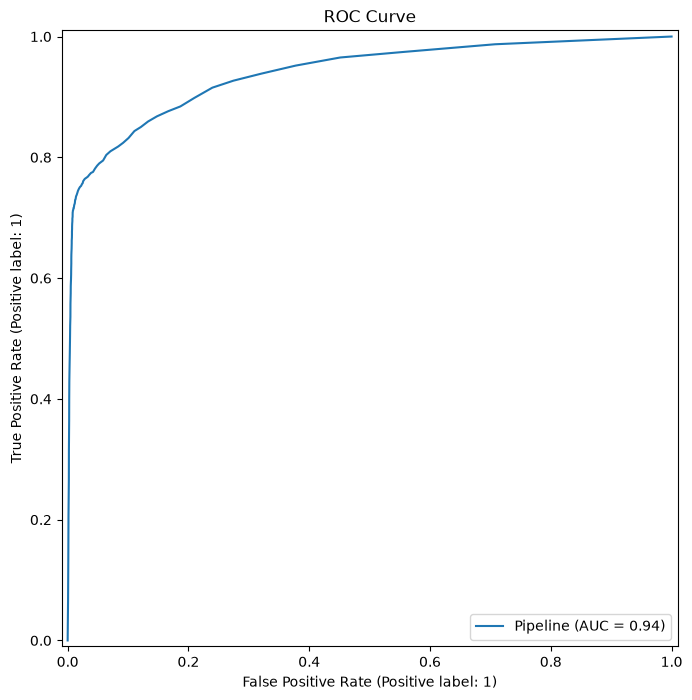

In [14]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(pipeline, X_val, y_val, ax=ax)
ax.set_title('ROC Curve')

## 8. Model Optimization

**At which point should we stop giving loans?**

We should stop giving loans away **the moment that our profit is lower than the loss of giving the loan**. In other words our goal is to minimize the profit sacrificed (FP) while maximizing the loss avoided (TP). At this point we are giving the loans the moment the probability of being a good loan is greater that 0.5. But this may not be the optimal point because the money we lose by giving a loan to a bad applicant is not the same as the money we win by giving a loan to a good applicant when we are 50% sure about our choice.

```plaintext
objective = Maximize(Amount of money we lose by TP - Amount of money we win by FP)

First we compute the probabilities of being correctly predicting a bad loan (true positive):

In [15]:
y_probs = pipeline.predict_proba(X_val)
y_tp_probs = y_probs[:, 1]  # 1 == bad loan

Then we compute the False Positives Ratio (FPR)  and the True Positives Ratio (TPR) for each threshold.

In [16]:
from sklearn.metrics import roc_curve


fpr, tpr, thresholds = roc_curve(y_val, y_tp_probs)

Finally we compute the optimal point by maximizing the objective function: maximizing the difference between the True Positives and the False Positives.

In [17]:
import numpy as np


optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
fpr_optimal = fpr[optimal_idx]
tpr_optimal = tpr[optimal_idx]

print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'FPR: {fpr_optimal:.4f}')
print(f'TPR: {tpr_optimal:.4f}')

Optimal threshold: 0.2000
FPR: 0.0639
TPR: 0.8039


We compare the AUC when we use the threshold of 0.5 (default).

In [18]:
average_idx = len(thresholds) // 2
average_threshold = thresholds[average_idx]
fpr_average = fpr[average_idx]
tpr_average = tpr[average_idx]

print(f'Average threshold: {average_threshold:.4f}')
print(f'FPR: {fpr_average:.4f}')
print(f'TPR: {tpr_average:.4f}')

Average threshold: 0.5000
FPR: 0.0108
TPR: 0.7211


Plot the AUC for the optimal threshold and the default threshold.

Text(0.010805987905224546, 0.7210718635809987, 'Average Threshold: 0.50')

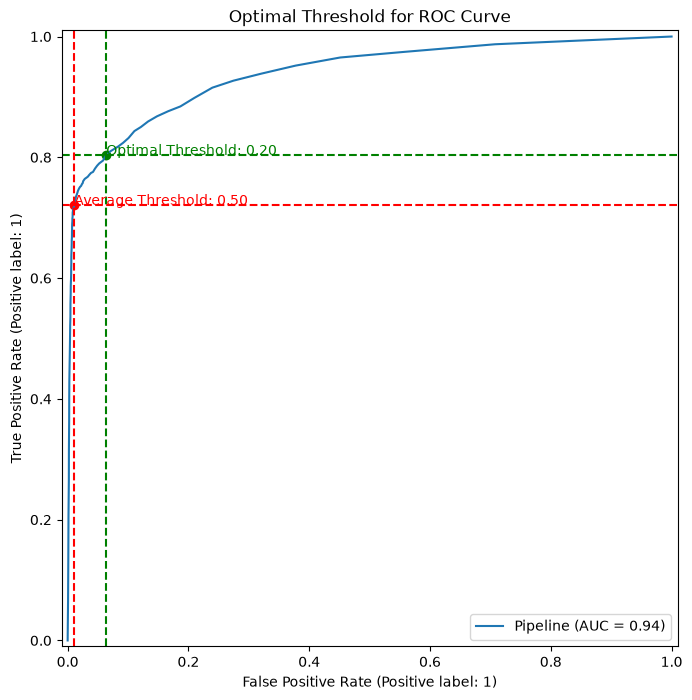

In [19]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(pipeline, X_val, y_val, ax=ax)
ax.set_title('Optimal Threshold for ROC Curve')

# add optimal point coordinates
ax.axvline(fpr_optimal, color='g', linestyle='--')
ax.axhline(tpr_optimal, color='g', linestyle='--')
ax.scatter(fpr_optimal, tpr_optimal, color='green')  # Añadir el punto
ax.text(fpr_optimal, tpr_optimal, f'Optimal Threshold: {optimal_threshold:.2f}', color='green')

# add average point coordinates
ax.axvline(fpr_average, color='r', linestyle='--')
ax.axhline(tpr_average, color='r', linestyle='--')
ax.scatter(fpr_average, tpr_average, color='red')  # Añadir el punto
ax.text(fpr_average, tpr_average, f'Average Threshold: {average_threshold:.2f}', color='red')

Add this tunning step to the pipeline.

In [20]:
from sklearn.model_selection import TunedThresholdClassifierCV


model = TunedThresholdClassifierCV(pipeline, scoring="roc_auc")

Train the model again with the new pipeline.

In [21]:
model.fit(X_train, y_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...m_state=42))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'roc_auc'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",None
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary <random_state>`.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
Name,Type,Value
"best_score_ best_score_: float or NoneThe optimal score of the objective metric, evaluated at `best_threshold_`.",float64,0.8628


Evaluate the model

In [22]:
from sklearn.metrics import roc_auc_score


y_pred = model.predict(X_val)
auc_metric = roc_auc_score(y_val, y_pred)

print(f'AUC: {auc_metric:.4f}')

AUC: 0.8700


In [23]:
import numpy as np
from sklearn.metrics import roc_curve


y_tp_probs = model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_tp_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = model.best_threshold_
fpr_optimal = fpr[optimal_idx]
tpr_optimal = tpr[optimal_idx]

print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'FPR: {fpr_optimal:.4f}')
print(f'TPR: {tpr_optimal:.4f}')

Optimal threshold: 0.1919
FPR: 0.0639
TPR: 0.8039


Plot the ROC curve and the optimal threshold

Text(0.010805987905224546, 0.7210718635809987, 'Average Threshold: 0.50')

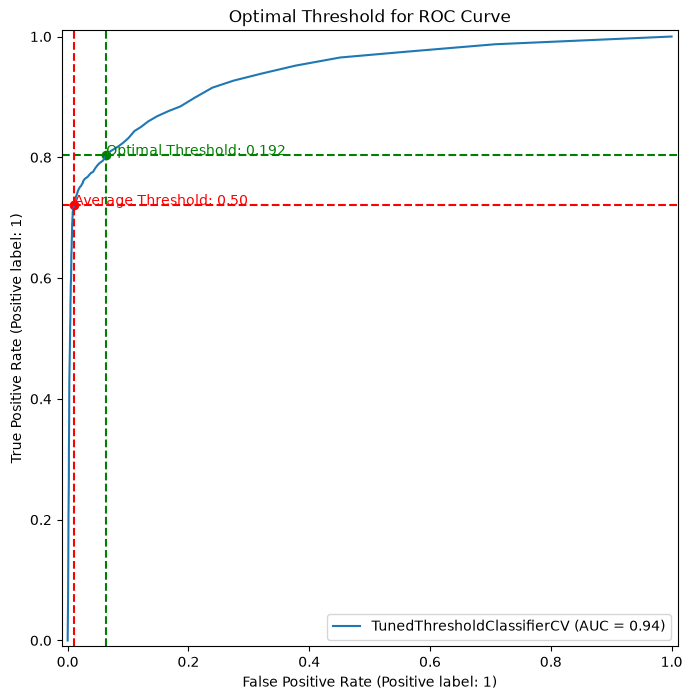

In [24]:
# Display the ROC Curve
fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax)
ax.set_title('Optimal Threshold for ROC Curve')


# add optimal point coordinates
ax.axvline(fpr_optimal, color='g', linestyle='--')
ax.axhline(tpr_optimal, color='g', linestyle='--')
ax.scatter(fpr_optimal, tpr_optimal, color='green')  # Añadir el punto
ax.text(fpr_optimal, tpr_optimal, f'Optimal Threshold: {optimal_threshold:.3f}', color='green')

# add average point coordinates
ax.axvline(fpr_average, color='r', linestyle='--')
ax.axhline(tpr_average, color='r', linestyle='--')
ax.scatter(fpr_average, tpr_average, color='red')  # Añadir el punto
ax.text(fpr_average, tpr_average, f'Average Threshold: {average_threshold:.2f}', color='red')

### Generate submission file

Looking at the `submission_sample.csv` file we see that it hmut have two columns: `id` and `loan_status`. The `id` column must have the same values as the test set and the `loan_status` column must have the predictions.

In [26]:
# Save the CSV to be submitted to a file
SUBMISSION_CSV_PATH = DATA_FOLDER + 'submission.csv'

# obtain the predictions
y_test_pred = model.predict(test_df)


# prepare the data to be submitted
ids_column = test_df.index
submission_data = {
    "id": ids_column,
    "loan_status": y_test_pred
}

# save it to a CSV file
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv(SUBMISSION_CSV_PATH, index=False)
submission_df.head()

,id,loan_status
0,58645,1
1,58646,0
2,58647,1
3,58648,0
4,58649,0


## 9. Model Tracking

Once we have trained the model we can use the MLFlow library to track the model performance. We can log the AUC, the metrics, the submission file...

### Connect to MLFlow

In [29]:
import mlflow


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("loan_prediction")

2026/09/25 14:58:05 INFO mlflow.tracking.fluent: Experiment with name 'loan_prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1790341085858, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790341085858, lifecycle_stage='active', name='loan_prediction', tags={}, trace_location=None, workspace='default'>

### Submit to MLFlow

In [33]:
with mlflow.start_run():

    mlflow.set_tag("model", model.__class__.__name__)

    mlflow.log_metric("auc", auc_metric)
    mlflow.log_metric("optimal_threshold", optimal_threshold)
    mlflow.log_metric("fpr_optimal", fpr_optimal)
    mlflow.log_metric("tpr_optimal", tpr_optimal)
    mlflow.log_metric("average_threshold", average_threshold)
    mlflow.log_metric("fpr_average", fpr_average)
    mlflow.log_metric("tpr_average", tpr_average)

    mlflow.sklearn.log_model(
        model,
        name="model",
        skops_trusted_types=[
            "sklearn.metrics._ranking.roc_auc_score",
            "sklearn.metrics._scorer._CurveScorer",
            "sklearn.metrics._scorer._Scorer",
            "sklearn.tree._tree.Tree",
            "sklearn.utils._metadata_requests.MetadataRequest",
            "sklearn.utils._metadata_requests.MethodMetadataRequest",
        ],
    )

    mlflow.log_artifact(SUBMISSION_CSV_PATH)

🏃 View run ambitious-deer-694 at: http://127.0.0.1:5000/#/experiments/1/runs/98f55631a65a4debbe89554df326f102
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [37]:
import mlflow

run_id = "98f55631a65a4debbe89554df326f102"

artifacts = mlflow.MlflowClient().list_artifacts(run_id)

for artifact in artifacts:
    print(artifact.path)

submission.csv


In [38]:
local_path = mlflow.artifacts.download_artifacts(
    run_id="98f55631a65a4debbe89554df326f102",
    artifact_path="submission.csv"
)

print(local_path)

/var/folders/h2/k72slh61129057msxtg1dmtm0000gn/T/tmp1khg94b9/submission.csv


In [39]:
import pandas as pd

submission = pd.read_csv(local_path)

print(submission.head())
print(submission.shape)
print(submission.columns)



      id  loan_status
0  58645            1
1  58646            0
2  58647            1
3  58648            0
4  58649            0
(39098, 2)
Index(['id', 'loan_status'], dtype='str')


## 10. Kaggle Submission


Finally we can submit the predictions to the kaggle platfrom. To do so we are going to retrieve the submission CSV from the best MLFlow run and submit it to the kaggle platform. You could upload the results manually by going to the kaggle website and clicking on `Submit Predictions`. You can then upload the file and submit it. Or you can use the kaggle API to submit the file:

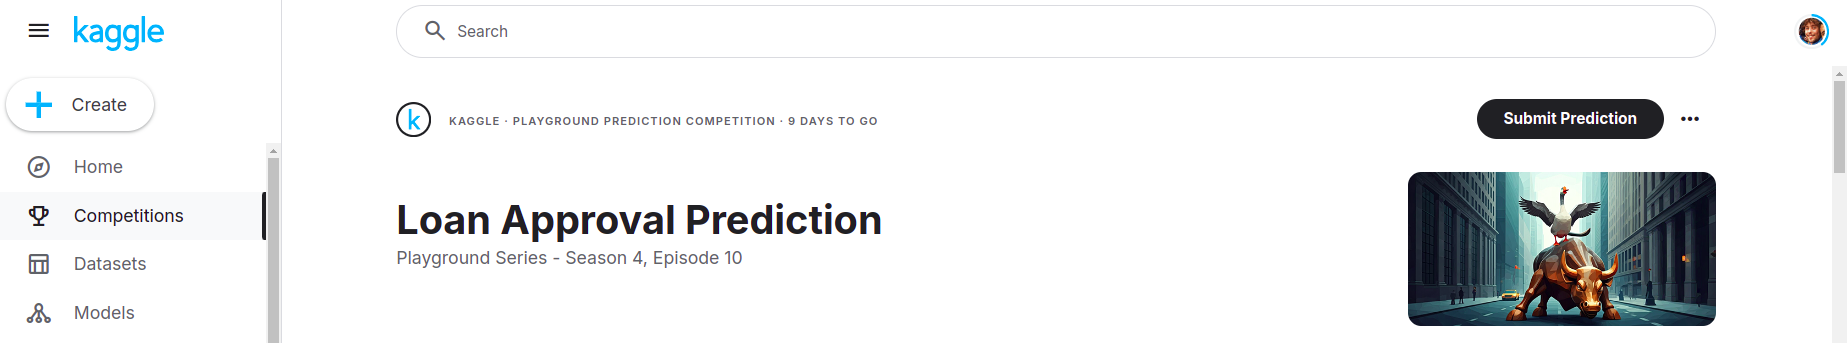

In [42]:
!kaggle competitions submit \
    -c playground-series-s4e10 \
    -f "{local_path}" \
    -m "Submission from MLflow run 98f55631"

100%|████████████████████████████████████████| 305k/305k [00:00<00:00, 377kB/s]
99 submissions remaining today.
Successfully submitted to Loan Approval Prediction

### 🎉 My Submission!:

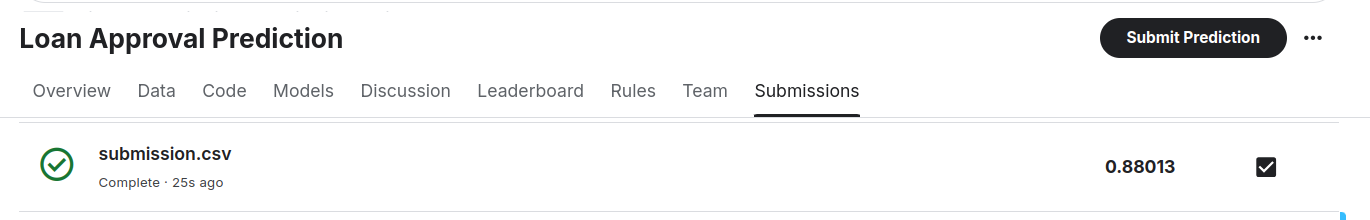

In [43]:
!kaggle competitions submissions -c playground-series-s4e10

     ref  fileName        date                        description                          status                     publicScore  privateScore  
--------  --------------  --------------------------  -----------------------------------  -------------------------  -----------  ------------  
56551506  submission.csv  2026-09-25 13:17:40.477000  Submission from MLflow run 98f55631  SubmissionStatus.COMPLETE  0.87680      0.86510       
